In [1]:
import torch as t
import numpy as np 
import torch.nn as nn
import torch.optim as optim 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
import os
import imageio
import glob
import io
import imageio.v2 as imageio
from Functions import *
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": "" 
})

In [2]:
DTYPE = t.float32
NP_DTYPE = np.float32 if DTYPE == t.float32 else np.float64
device = t.device('cuda' if t.cuda.is_available() else 'cpu')

#PINN architecture
class adaptive_tanh(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.beta = nn.Parameter(t.zeros(1, num_features))

    def forward(self, x):
        return (1 + self.beta*x)*t.tanh(x)

class Model(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels, num_hidden_layers=2, rho_init = None):
        super().__init__() 
        self.input_layer = nn.Linear(in_channels, hidden_channels)
        self.act_input = adaptive_tanh(hidden_channels)

        self.hidden_layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        for _ in range(num_hidden_layers):
            self.hidden_layers.append(nn.Linear(hidden_channels, hidden_channels))
            self.activations.append(adaptive_tanh(hidden_channels))

        self.output_layer = nn.Linear(hidden_channels, out_channels) 

        self.rho_re = nn.Parameter(t.tensor(rho_init.real, dtype = DTYPE), requires_grad = False)
        self.rho_im = nn.Parameter(t.tensor(rho_init.imag, dtype = DTYPE), requires_grad = False)

    def forward(self, x: t.tensor):
        x = self.input_layer(x)
        x = self.act_input(x)

        for layer, act in zip(self.hidden_layers, self.activations):
            x = layer(x)
            x = act(x)

        x = self.output_layer(x) 
        return x 

In [3]:
checkpoint_path = './Pretrained_Models/pinn_checkpoint_qnm_l2_delta0.6_run0.pth'
checkpoint = t.load(checkpoint_path, map_location = device, weights_only = False)
rho_re_saved, rho_im_saved = checkpoint['final_rho']
rho_init = complex(rho_re_saved, rho_im_saved)

model = Model(1, 2, 32, num_hidden_layers = 3, rho_init = rho_init).to(dtype = DTYPE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Loaded model with rho = {model.rho_re.item():.6f} + {model.rho_im.item():.6f}i")

final_omega = complex(-model.rho_im.item(), model.rho_re.item())
print(f"Final omega = {final_omega.real:.6f} + {final_omega.imag:.6f}i")

omega_history = {'re': -checkpoint['rho_history']['im'], 'im': checkpoint['rho_history']['re']}
loss_history = checkpoint['loss_history']
rho_history = checkpoint['rho_history']

print(checkpoint.keys())


Loaded model with rho = -0.177913 + -0.747238i
Final omega = 0.747238 + -0.177913i
dict_keys(['model_state_dict', 'rho_history', 'loss_history', 'final_rho', 'final_ode_residual'])


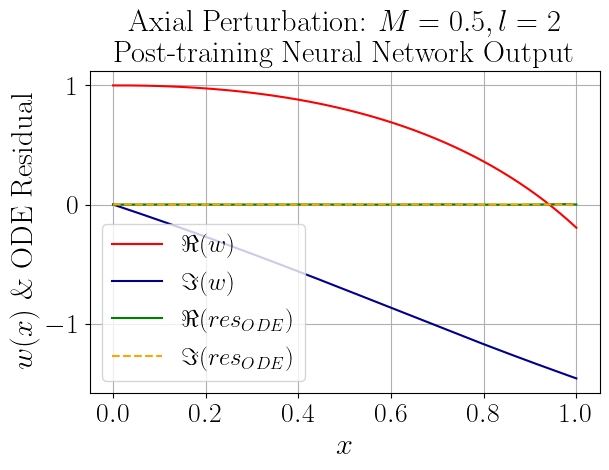

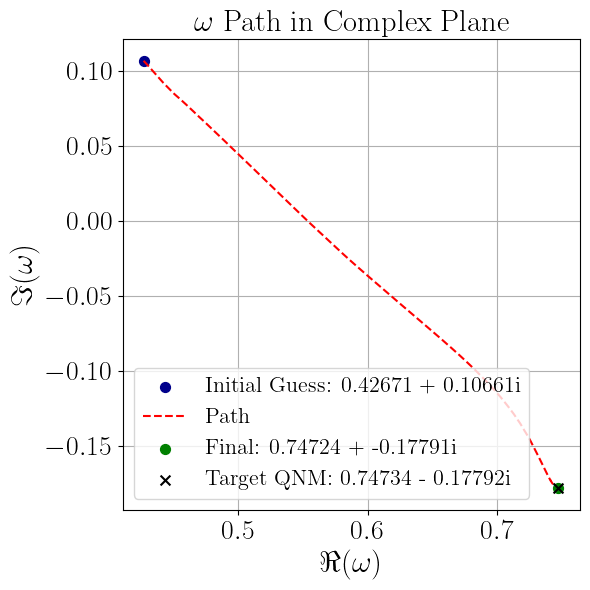

In [4]:
x_eval = t.linspace(0, 1, 5000, dtype = DTYPE, device = device).view(-1, 1)

x_res = checkpoint['final_ode_residual']['x']
res_re = checkpoint['final_ode_residual']['res_re']
res_im = checkpoint['final_ode_residual']['res_im']

with t.no_grad():
    w_out = model(x_eval)
    w_re = w_out[:, 0].cpu().numpy()
    w_im = w_out[:, 1].cpu().numpy()

x_np = x_eval.cpu().numpy().flatten()

# print(len(checkpoint['loss_history']['ode']))

plt.figure()
plt.plot(x_np, w_re, color = 'red', label = r'$\Re(w)$')
plt.plot(x_np, w_im, color = 'darkblue', label = r'$\Im(w)$')
plt.plot(x_res, res_re, color = 'green', label = r'$\Re(res_{ODE})$')
plt.plot(x_res, res_im, color = 'orange', linestyle = '--', zorder = 10, label = r'$\Im(res_{ODE})$')
plt.title(r'Axial Perturbation: $M = 0.5, l = 2$'
    '\n'
    'Post-training Neural Network Output', fontsize = 22)
plt.xlabel(r'$x$', fontsize = 22)
plt.ylabel(r'$w(x)$ \& ODE Residual', fontsize = 22)
plt.legend(fontsize = 18, loc = 'lower left')
plt.tick_params(labelsize = 20)
plt.grid()
plt.tight_layout()
plt.savefig('./PINNFigures/wOutput.png', format = 'png')

plt.figure(figsize = [6, 6])
plt.scatter(omega_history['re'][0], omega_history['im'][0], marker = 'o', s = 50, color = 'darkblue', label = f'Initial Guess: {omega_history["re"][0]:.5f} + {omega_history["im"][0]:.5f}i')
plt.plot(omega_history['re'], omega_history['im'], 'r--', label = 'Path')
plt.scatter(omega_history['re'][-1], omega_history['im'][-1], marker = 'o', s= 50, zorder = 4, color = 'green', label = f'Final: {omega_history["re"][-1]:.5f} + {omega_history["im"][-1]:.5f}i')
plt.scatter(0.74734, -0.17792, marker = 'x',  zorder = 5, color = 'k', s = 50, label = 'Target QNM: 0.74734 - 0.17792i')
plt.xlabel(r'$\Re(\omega)$', fontsize = 22)
plt.ylabel(r'$\Im(\omega)$', fontsize = 22)
plt.tick_params(labelsize = 20)
plt.legend(fontsize = 16, loc = 'lower left')
plt.title(r'$\omega$ Path in Complex Plane', fontsize = 22)
plt.grid()
plt.tight_layout()
plt.savefig('./PINNFigures/rhoconvergence.png', format = 'png')

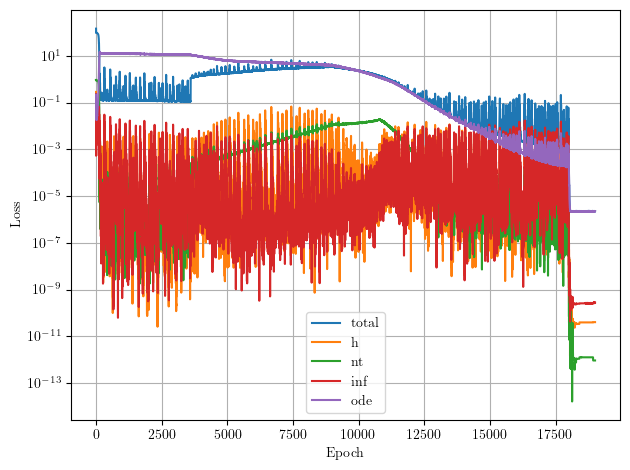

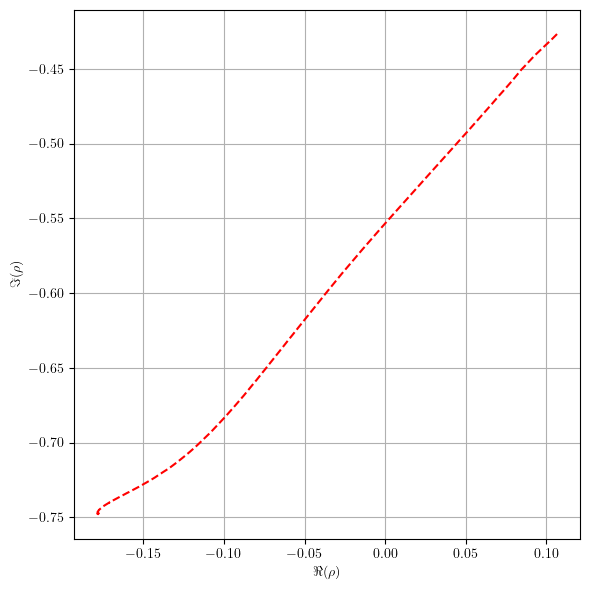

In [5]:

plt.figure()
for key, vals in loss_history.items():
    plt.plot(vals, label = key)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize = [6, 6])
plt.plot(rho_history['re'][0], rho_history['im'][0], label = 'Initial Guess')
plt.plot(rho_history['re'], rho_history['im'], 'r--', label = 'Path')
plt.xlabel(r'$\Re(\rho)$')
plt.ylabel(r'$\Im(\rho)$')
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
x_eval = t.linspace(1e-7, 1 - 1e-5, 10000, dtype = DTYPE, device = device).view(-1, 1)
x_np = x_eval.cpu().numpy().flatten()
r_np = 1.0/(1.0 - x_np)
rstar_np = r_to_rstar(r_np, 0.5)

print(rstar_np[0])

final_rho = complex(rho_re_saved, rho_im_saved)
final_omega = 1j*final_rho

with t.no_grad():
    w_out = model(x_eval)
    w_re = w_out[:, 0].cpu().numpy()
    w_im = w_out[:, 1].cpu().numpy()

w_complex = w_re + 1j*w_im

boundary_factor = np.exp(-x_np*final_rho/(x_np - 1))*(1 - x_np)**(-3*final_rho)*x_np**(final_rho)
Psi_spatial = boundary_factor*w_complex
Psi_spatial = np.reshape(Psi_spatial, (1, -1))

r_min, r_max = 0.95, 25.0
mask = (r_np >= r_min) & (r_np <= r_max)
r_plot = r_np[mask]
rstar_plot = rstar_np[mask]

T_osc = 2*np.pi/final_omega.real
t_dec = -1.0/final_omega.imag
t_end = min(5.0*T_osc, 4.0*t_dec)
t_vals = np.linspace(0, t_end, 200)
phi_t = np.exp(-1j*final_omega*t_vals)
phi_t = np.reshape(phi_t, (1, -1))

Psi_xt = np.matmul(Psi_spatial.transpose(), phi_t).transpose()
h1 = Psi_xt*(x_np)/r_np

Psi_masked = Psi_xt[:, mask]
h1_masked  = h1[:, mask]
# psi_ylim   = 1.4*np.max(np.abs(Psi_masked))
# h1_ylim    = 1.4*np.max(np.abs(h1_masked))

def create_frame(n, r, Psi):

    plt.figure(figsize = [7, 6])
    plt.plot(r, Psi.real[n, :], color = 'red', label = r'$\Re(\Psi)$')
    plt.plot(r, Psi.imag[n, :], color = 'darkblue', label = r'$\Im(\Psi)$')
    plt.xlim(r.min(), r.max())
    plt.ylim(-1.5, 1.5)
    plt.xlabel(r'$r/2M$', fontsize = 22)
    plt.ylabel(r'$\Psi(r(x), t)$', fontsize = 22)
    plt.axhline(0, color = 'k', linestyle = '--')
    plt.title(r'$\Psi(x, t) = \Gamma(x) w(x) \cdot \exp{\left(-i \omega t\right)}$'
            '\n'
            rf'at $t = {t_vals[n]:.1f}/2M$', fontsize = 22)
    plt.tick_params(axis='both', which = 'major', labelsize = 18)
    plt.minorticks_on()
    plt.grid(True, which = 'both')
    plt.legend(fontsize = 18, loc = 'upper right')
    plt.tight_layout()

    plt.savefig(f'./PINNFigures/Movies/img_{n}.png', 
                    transparent = False,  
                    facecolor = 'white',
                    )
    plt.close()

frames = []
print('Generating GIF...')
for i in range(0, len(t_vals)):
    create_frame(i, r_plot, Psi_masked)
    image = imageio.imread(f'./PINNFigures/Movies/img_{i}.png')
    frames.append(image)
imageio.mimsave(f'./PINNFigures/Movies/Movie.gif', frames, fps = 10, loop=0)
print('Done!')

-14.942385
Generating GIF...
Done!


Generating GIF...
Done!


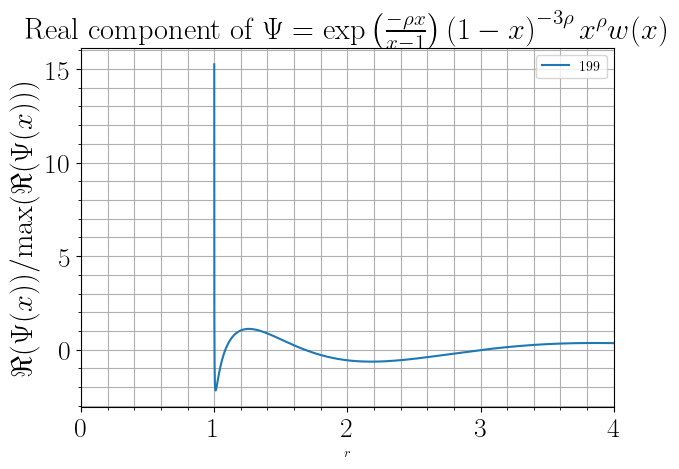

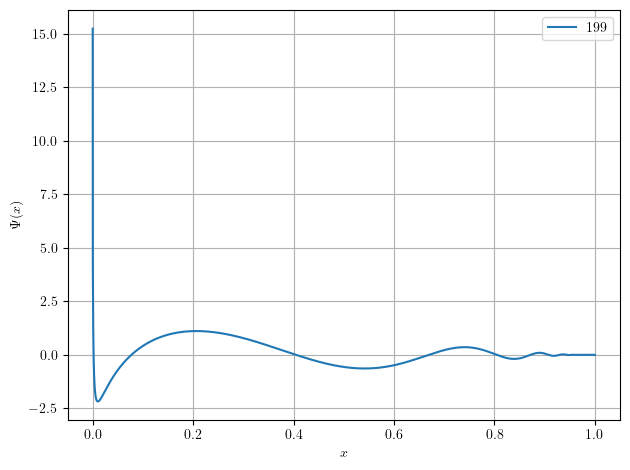

In [7]:

def create_frame(n, r, Psi, h):

    plt.figure(figsize = [12, 6])
    plt.suptitle(rf'$t = {t_vals[n]:.1f}/2M$', fontsize = 22, y=1.0)
    plt.subplot(1, 2, 1)
    plt.plot(r, Psi.real[n, :], color = 'red', label = r'$\Re(\Psi)$')
    plt.plot(r, Psi.imag[n, :], color = 'darkblue', label = r'$\Im(\Psi)$')
    plt.xlim(r.min(), r.max())
    plt.ylim(-2, 2)
    plt.xlabel(r'$r/2M$', fontsize = 22)
    plt.ylabel(r'$\Psi$', fontsize = 22)
    plt.axhline(0, color = 'k', linestyle = '--')
    plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
    plt.title(r'Time evolution of $\Psi = \exp{\left(\frac{-\rho x}{x-1}\right)\left(1-x\right)^{-3 \rho}x^{\rho}w(x)}$', fontsize = 22)
    plt.tick_params(axis='both', which = 'major', labelsize = 18)
    plt.minorticks_on()
    plt.grid(True, which = 'both')
    plt.legend(fontsize = 18, loc = 'upper right')

    plt.subplot(1, 2, 2)
    plt.plot(r, h.real[n, :], color = 'red', label = r'$\Re(h_1)$')
    plt.plot(r, h.imag[n, :], color = 'darkblue', label = r'$\Im(h_1)$')
    plt.xlabel(r'$r/2M$', fontsize = 22)
    plt.xlim(r.min(), r.max())
    plt.ylim(-0.2, 0.2)
    plt.axhline(0.0, color = 'k', linestyle = '--')
    plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
    plt.tick_params(axis='both', which = 'major', labelsize = 20)
    plt.minorticks_on()
    plt.grid(True, which = 'both')
    plt.ylabel(r'$h_1$', fontsize = 22)
    plt.title(r'Time evolution of $h_1 = \left(1 - \frac{2M}{r}\right)\frac{\Psi}{r}$', fontsize = 22)
    plt.legend(fontsize = 18, loc = 'upper right')

    plt.subplots_adjust(left = 0.08, right = 0.95, bottom = 0.15, top = 0.85, wspace = 0.25)
    plt.savefig(f'./PINNFigures/Movies/img_{n}.png', 
                    transparent = False,  
                    facecolor = 'white',
                    )
    plt.close()

frames = []
print('Generating GIF...')
for i in range(0, len(t_vals)):
    create_frame(i, r_plot, Psi_masked, h1_masked)
    image = imageio.imread(f'./PINNFigures/Movies/img_{i}.png')
    frames.append(image)
imageio.mimsave(f'./PINNFigures/Movies/Movie.gif', frames, fps = 10, loop=0)


print('Done!')

plt.figure()
plt.plot(r_np, Psi_xt[0, :].real, label = f'{i}')
plt.xlim(left = 0, right = 4)
plt.title(r'Real component of $\Psi = \exp{\left(\frac{-\rho x}{x-1}\right)\left(1-x\right)^{-3 \rho}x^{\rho}w(x)}$', fontsize = 22)
plt.tick_params(axis='both', which = 'major', labelsize = 20)
plt.minorticks_on()
plt.grid(True, which = 'both')
plt.xlabel(r'$r$')
plt.ylabel(r'$\Re(\Psi(x))/$max$(\Re(\Psi(x)))$', fontsize = 22)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(x_np, Psi_xt[0, :].real, label = f'{i}')
# plt.xlim(left = 0, right = 4)
plt.xlabel(r'$x$')
plt.ylabel(r'$\Psi(x)$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

(200, 10000) (10000,) (10000,)
(10000,)


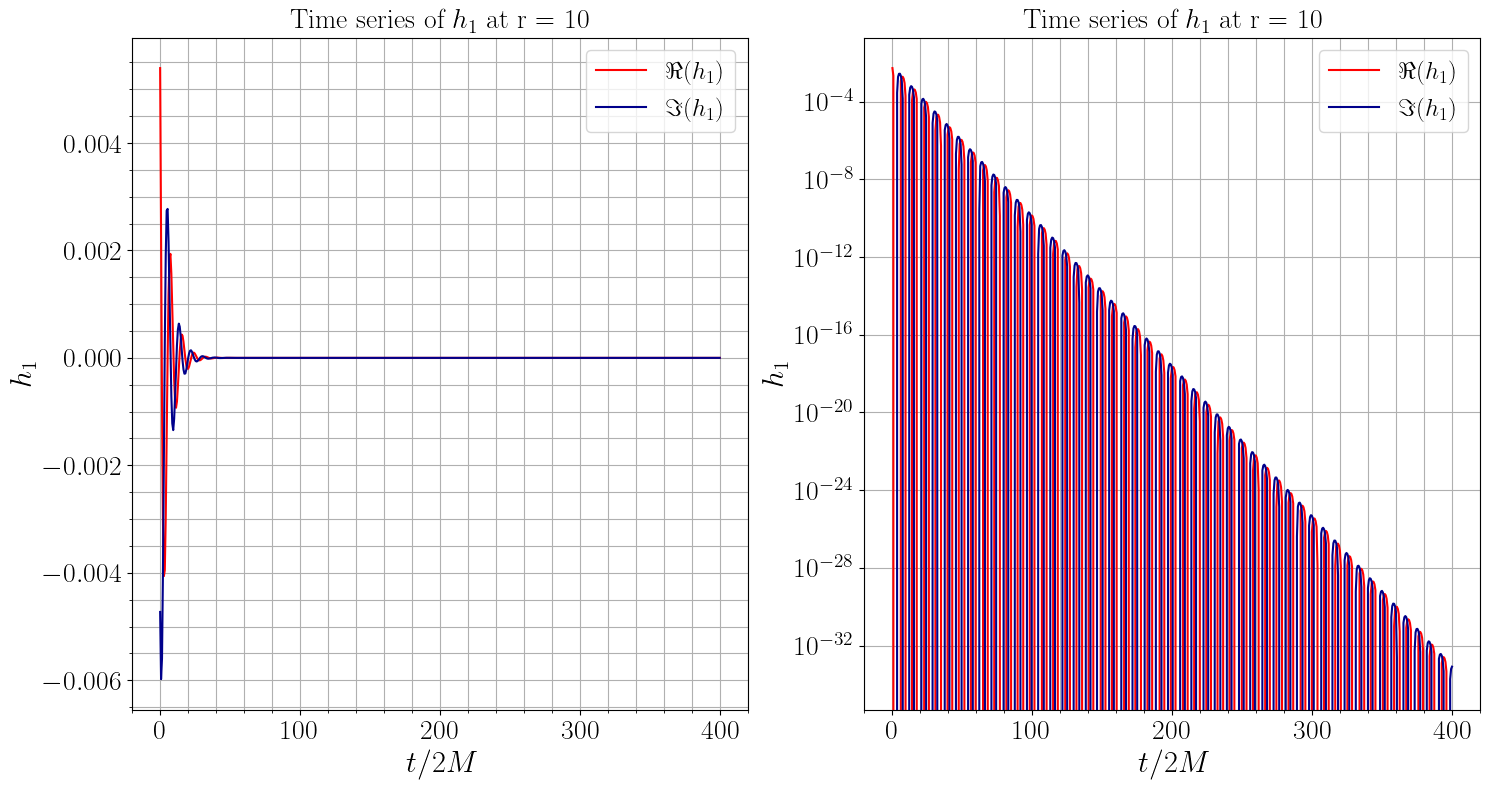

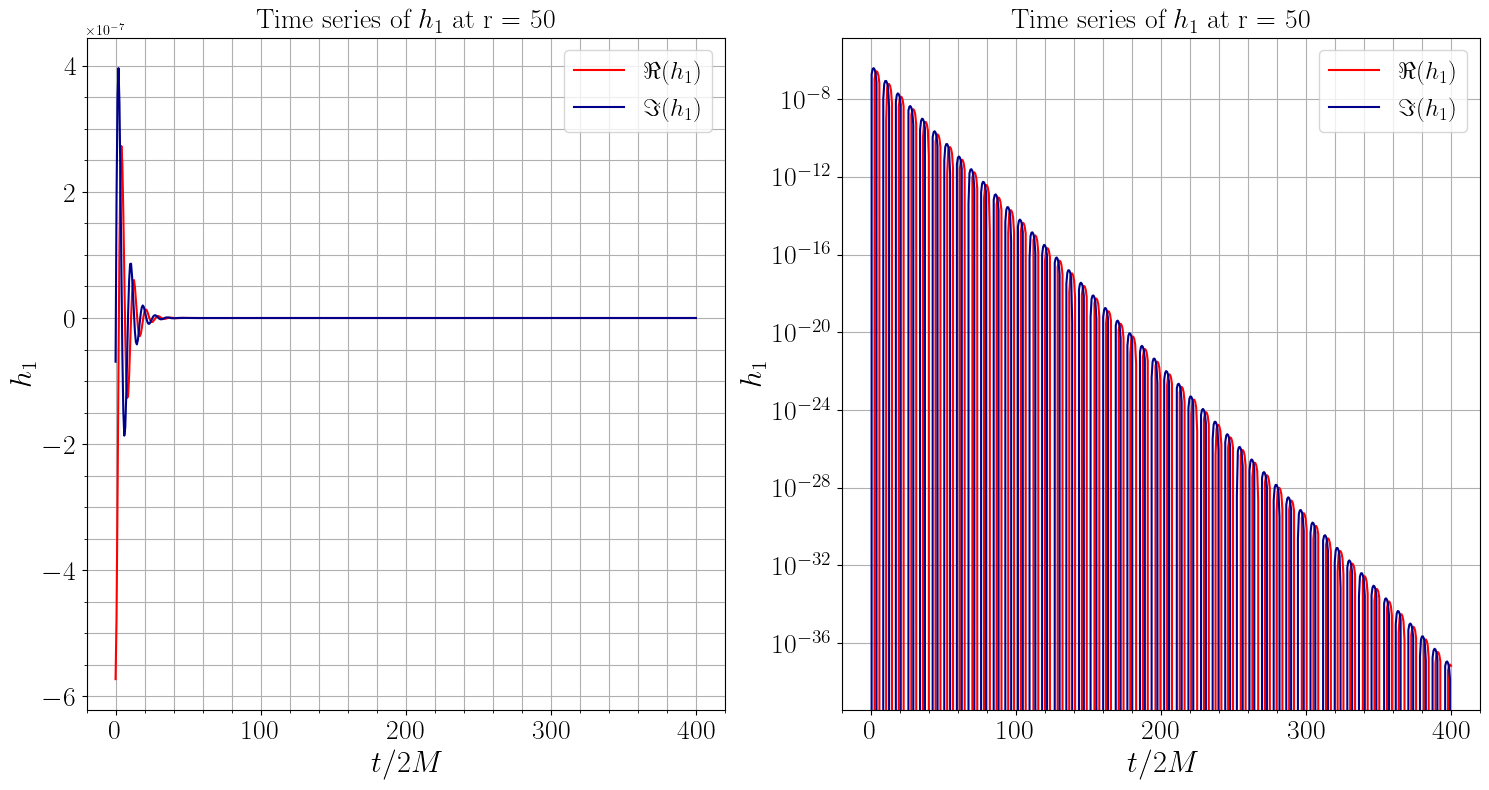

In [8]:
print(Psi_xt.shape, x_np.shape, r_np.shape)

idx1 = np.argmin(np.abs(r_np - 10))
idx2 = np.argmin(np.abs(r_np - 50))

print(x_np.shape)

new_t_vals = np.linspace(0, 400, 600)
new_phi_t = np.exp(-1j*final_omega*new_t_vals)
new_phi_t = np.reshape(new_phi_t, (1, -1))

new_Psi_xt = np.matmul(Psi_spatial.transpose(), new_phi_t).transpose()
new_h1 = new_Psi_xt*x_np/r_np

plt.figure(figsize = [15, 8])
plt.subplot(1, 2, 1)
plt.plot(new_t_vals, new_h1.real[:, idx1], color = 'red', label = r'$\Re(h_1)$')
plt.plot(new_t_vals, new_h1.imag[:, idx1], color = 'darkblue', label = r'$\Im(h_1)$')
plt.xlabel(r'$t/2M$', fontsize = 22)
# plt.xlim(r_np.min(), r_np.max())
# plt.ylim(-0.2, 0.2)
# plt.axhline(0.0, color = 'k', linestyle = '--')
# plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
plt.title('Time series of $h_1$ at r = 10', fontsize = 20)
plt.tick_params(axis='both', which = 'major', labelsize = 20)
plt.minorticks_on()
plt.grid(True, which = 'both')
plt.ylabel(r'$h_1$', fontsize = 22)
plt.legend(fontsize = 18, loc = 'upper right')

plt.subplot(1, 2, 2)
plt.plot(new_t_vals, new_h1.real[:, idx1], color = 'red', label = r'$\Re(h_1)$')
plt.plot(new_t_vals, new_h1.imag[:, idx1], color = 'darkblue', label = r'$\Im(h_1)$')
plt.xlabel(r'$t/2M$', fontsize = 22)
# plt.xlim(r_np.min(), r_np.max())
# plt.ylim(-0.2, 0.2)
# plt.axhline(0.0, color = 'k', linestyle = '--')
# plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
plt.title('Time series of $h_1$ at r = 10', fontsize = 20)
plt.tick_params(axis='both', which = 'major', labelsize = 20)
plt.yscale('log')
plt.minorticks_on()
plt.grid(True, which = 'both')
plt.ylabel(r'$h_1$', fontsize = 22)
plt.legend(fontsize = 18, loc = 'upper right')
plt.tight_layout()
plt.savefig('./Ringdown.png', format = 'png')

plt.figure(figsize = [15, 8])
plt.subplot(1, 2, 1)
plt.plot(new_t_vals, new_h1.real[:, idx2], color = 'red', label = r'$\Re(h_1)$')
plt.plot(new_t_vals, new_h1.imag[:, idx2], color = 'darkblue', label = r'$\Im(h_1)$')
plt.xlabel(r'$t/2M$', fontsize = 22)
# plt.xlim(r_np.min(), r_np.max())
# plt.ylim(-0.2, 0.2)
# plt.axhline(0.0, color = 'k', linestyle = '--')
# plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
plt.title('Time series of $h_1$ at r = 50', fontsize = 20)
plt.tick_params(axis='both', which = 'major', labelsize = 20)
plt.minorticks_on()
plt.grid(True, which = 'both')
plt.ylabel(r'$h_1$', fontsize = 22)
plt.legend(fontsize = 18, loc = 'upper right')

plt.subplot(1, 2, 2)
plt.plot(new_t_vals, new_h1.real[:, idx2], color = 'red', label = r'$\Re(h_1)$')
plt.plot(new_t_vals, new_h1.imag[:, idx2], color = 'darkblue', label = r'$\Im(h_1)$')
plt.xlabel(r'$t/2M$', fontsize = 22)
# plt.xlim(r_np.min(), r_np.max())
# plt.ylim(-0.2, 0.2)
# plt.axhline(0.0, color = 'k', linestyle = '--')
# plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
plt.title('Time series of $h_1$ at r = 50', fontsize = 20)
plt.tick_params(axis='both', which = 'major', labelsize = 20)
plt.yscale('log')
plt.minorticks_on()
plt.grid(True, which = 'both')
plt.ylabel(r'$h_1$', fontsize = 22)
plt.legend(fontsize = 18, loc = 'upper right')
plt.tight_layout()
plt.show()

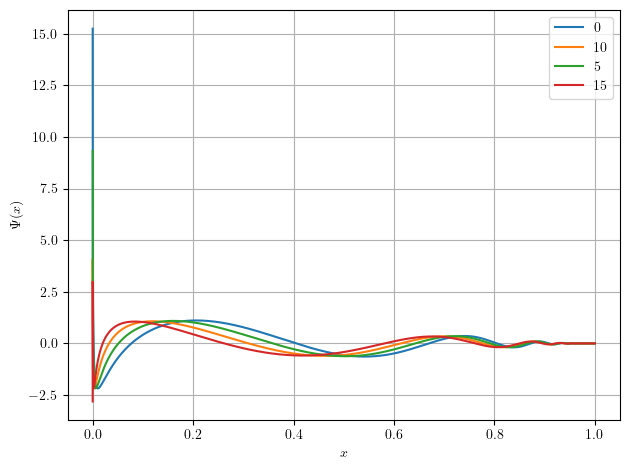

Generating GIF...


In [ ]:
plt.figure()
plt.plot(x_np, Psi_xt[0, :].real, label = '0')
plt.plot(x_np, Psi_xt[10,:].real, label = '10')
plt.plot(x_np, Psi_xt[5,:].real, label = '5')
plt.plot(x_np, Psi_xt[15,:].real, label = '15')
# plt.xlim(left = 0, right = 4)
plt.xlabel(r'$x$')
plt.ylabel(r'$\Psi(x)$')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
def create_frame(n, r, Psi):

    plt.figure(figsize = [6, 6])
    plt.suptitle(rf'$t = {t_vals[n]:.1f}/2M$', fontsize = 22, y=1.0)
    plt.plot(r, Psi.real[n, :], color = 'red', label = r'$\Re(\Psi)$')
    plt.plot(r, Psi.imag[n, :], color = 'darkblue', label = r'$\Im(\Psi)$')
    plt.xlim(r.min(), r.max())
    plt.ylim(-2, 2)
    plt.xlabel(r'$x$', fontsize = 22)
    plt.ylabel(r'$\Psi$', fontsize = 22)
    plt.axhline(0, color = 'k', linestyle = '--')
    plt.axvline(1.0, color = 'black', linewidth = 1.5, label = 'Event Horizon')
    plt.title(r'Time evolution of $\Psi(x) = \exp{\left(\frac{-\rho x}{x-1}\right)\left(1-x\right)^{-3 \rho}x^{\rho}w(x)}$', fontsize = 22)
    plt.tick_params(axis='both', which = 'major', labelsize = 18)
    plt.minorticks_on()
    plt.grid(True, which = 'both')
    plt.legend(fontsize = 18, loc = 'upper right')

    plt.subplots_adjust(left = 0.08, right = 0.95, bottom = 0.15, top = 0.85, wspace = 0.25)
    plt.savefig(f'./PINNFigures/Movies/imgx_{n}.png', 
                    transparent = False,  
                    facecolor = 'white',
                    )
    plt.close()

frames = []
print('Generating GIF...')
for i in range(0, len(t_vals)):
    create_frame(i, x_np, Psi_xt)
    image = imageio.imread(f'./PINNFigures/Movies/imgx_{i}.png')
    frames.append(image)
imageio.mimsave(f'./PINNFigures/Movies/Moviex.gif', frames, fps = 10, loop=0)

In [10]:
dir_path = "./PINNFigures/Movies"
file_pattern = "*.png"
file_paths = glob.glob(os.path.join(dir_path, file_pattern))
for file_path in file_paths:
    os.remove(file_path)